# Plan
 - Determine what n_tets / min_size / d0 combinations are feasable for the subjects with the highest cell counts
---
 #### Study3a
 - Ran for tpm and mc1
 - The two subjects with the highest cell counts (1 million ish) from study two
    - Not true, accidentatlly did 50045R instead of 14874
 - increased min_size from 0.02 to 0.05 to see what affect this has
---
#### Study3b/c/d
 - b / c: subjects with 6 highest cell counts
 - d: 3 subjects with normal cell counts and range of thicknesses
 - run for combos of d0 / n_tets / min_size - identify feasible combos
 - Set other params to determined values (thus far)
---

In [74]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from tqdm import tqdm

# Study3a
 - Initial run to see what difference increasing min_size from 0.02 to 0.05 makes
 #### Conclusion
 - increasing to 0.05 made a significant difference ~40% decrease in total cell count

In [2]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimise3D') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study3') # path dir to save outputs in

study_prefix = 'study3' # start of dir name of output_root in set_parameters
studies = ['a'] # individual study identifier (end of dir name of output_root in set_parameters)

In [16]:
# ORGANISE AND SAVE DATA

get_params3d(root_dir, study_prefix, studies).to_csv(out_dir / 'params-a.csv', index=False)
get_runtimes(root_dir, study_prefix, studies).to_csv(out_dir / 'runtimes-a.csv', index=False)

info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, ['study3a-0a'])
df_qual['tets_vol'] = df_qual['total_tets'] / df_qual['total_vol']
df_bone.to_csv(out_dir / 'df_bone-a.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart-a.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual-a.csv', index=False)

In [17]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone-a.csv')
df_cart = pd.read_csv(out_dir / 'df_cart-a.csv')
df_qual = pd.read_csv(out_dir / 'df_qual-a.csv')


df_run = pd.read_csv(out_dir / 'runtimes-a.csv')
df_param = pd.read_csv(out_dir / 'params-a.csv')
df_param

,sub,bone,run_id,cgal_params.sizing_field.d0,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound
0,50045R,tpm,0-0a,3,0.00500,0
1,50045R,tpm,1-0a,3,0.00500,20
2,50045R,tpm,2-0a,3,0.00500,30
3,50045R,tpm,3-0a,3,0.00250,0
4,50045R,tpm,4-0a,3,0.00250,20
...,...,...,...,...,...,...
103,50021R,mc1,22-0a,5,0.00250,20
104,50021R,mc1,23-0a,5,0.00250,30
105,50021R,mc1,24-0a,5,0.00125,0
106,50021R,mc1,25-0a,5,0.00125,20


In [15]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99%'
qual_part = 'cart'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',

    # cell count (keep low)
    'total_tets'

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'total_tets',
        'tets_vol'
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

54


50045R - Average edge length: 0.3666 mm
50021R - Average edge length: 0.3692 mm


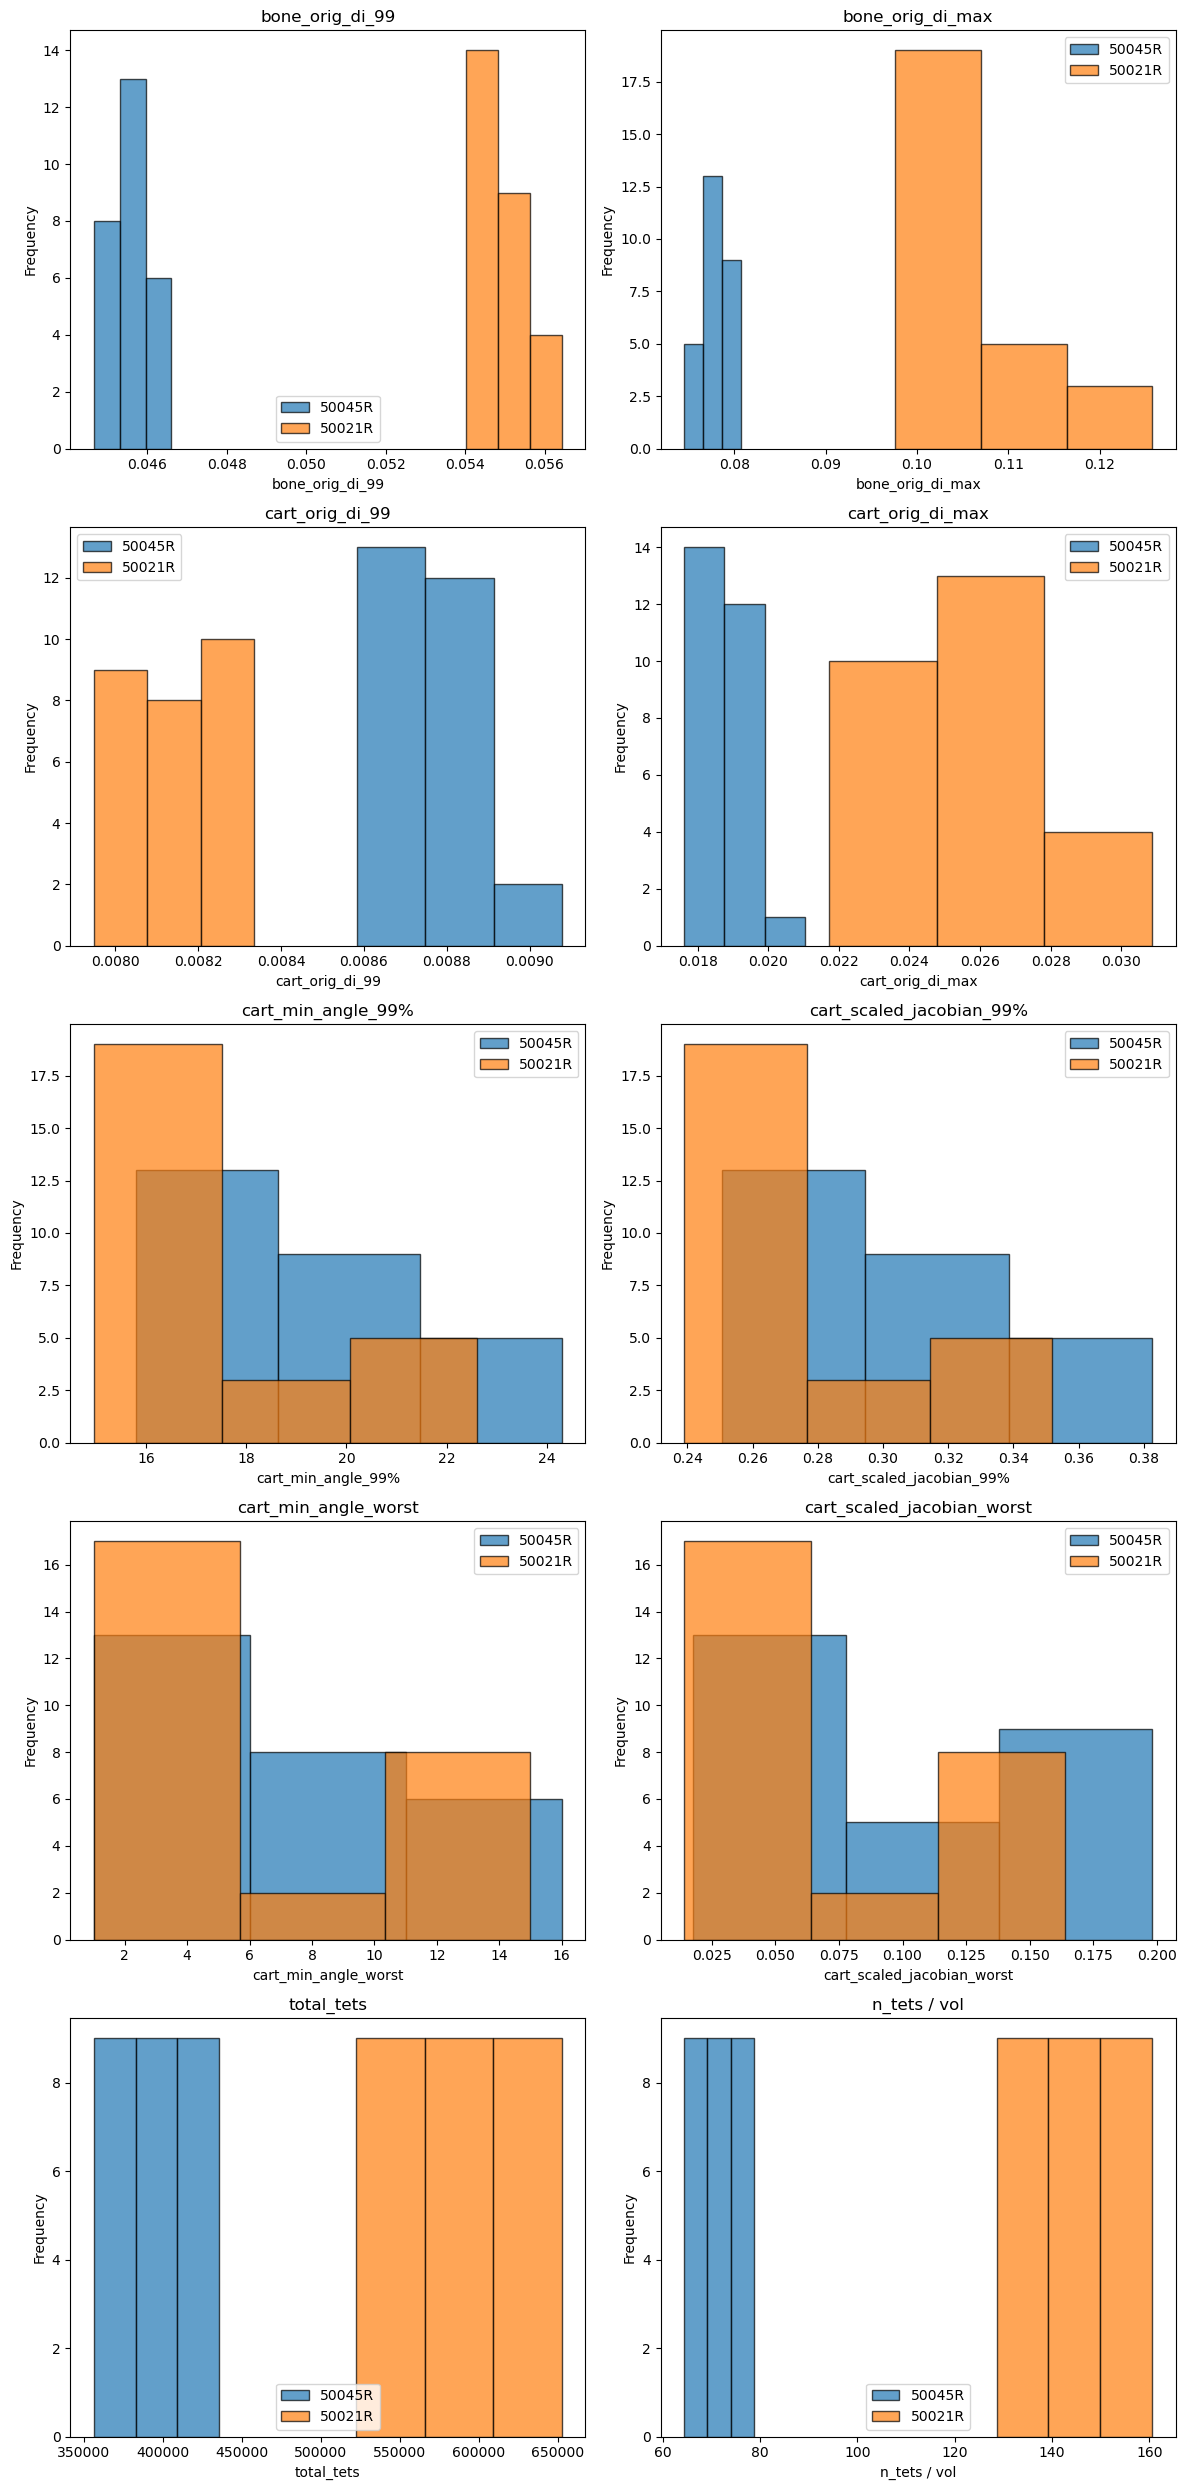

In [14]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()


for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    orig_vol = info[(info['subject']==int(subject)) & (info['side']==side)]['tpm_volume'].values
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    print(f"{sub} - Average edge length: {L:.4f} mm")

    sub_df = df[df['sub']==sub]
    bins = round(len(sub_df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        ax[i].legend()

    #ax[-1].hist(100 * (sub_df['remesh3d_vol'].values - orig_vol) / orig_vol, bins=bins, edgecolor='black', alpha=0.7)
    ax[-1].hist(sub_df['tets_vol'], bins=bins, edgecolor='black', alpha=0.7, label=sub)
    ax[-1].set_title("n_tets / vol")
    ax[-1].set_xlabel("n_tets / vol")
    ax[-1].set_ylabel('Frequency')
    ax[-1].legend()

plt.tight_layout()
plt.show()

# Study3b/c/d
 - b and c subjects with 6 highest cell counts ; d 3 subjects with normal cell counts and range of thicknesses
 - run for combos of d0 / n_tets / min_size - identify feasible combos
 - Set other params to determined values (thus far)

In [19]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimise3D') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study3') # path dir to save outputs in

study_prefix = 'study3' # start of dir name of output_root in set_parameters
studies = ['b', 'c', 'd'] # individual study identifier (end of dir name of output_root in set_parameters)

In [56]:
# ORGANISE AND SAVE DATA

params2 = get_params3d(root_dir, study_prefix, studies)
params1 = get_params3d(root_dir, study_prefix, ['b'], full_param_file='full_params-1.json')
pd.concat((params1, params2)).to_csv(out_dir / 'params.csv', index=False)
runs2 = get_runtimes(root_dir, study_prefix, studies)
runs1 = get_runtimes(root_dir, study_prefix, ['b'], 'full_params-1.json')
pd.concat((runs1, runs2)).to_csv(out_dir / 'runtimes.csv', index=False)

info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, ['study3b-1b', 'study3b-0b', 'study3c-0c', 'study3d-0d'])
df_qual['tets_vol'] = df_qual['total_tets'] / df_qual['total_vol']
df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [57]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')


df_run = pd.read_csv(out_dir / 'runtimes.csv')
df_param = pd.read_csv(out_dir / 'params.csv')
df_param

,sub,bone,run_id,cgal_params.sizing_field.n_tets,cgal_params.sizing_field.min_size,cgal_params.sizing_field.d0
0,14874R,tpm,0-1b,2,0.02,2
1,14874R,tpm,1-1b,2,0.02,4
2,14874R,tpm,2-1b,2,0.02,6
3,14874R,tpm,3-1b,2,0.02,8
4,14874R,tpm,4-1b,2,0.04,2
...,...,...,...,...,...,...
426,22306R,tpm,43-0d,4,0.06,8
427,22306R,tpm,44-0d,4,0.08,2
428,22306R,tpm,45-0d,4,0.08,4
429,22306R,tpm,46-0d,4,0.08,6


In [114]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',

    # cell count (keep low)
    'total_tets'

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'total_tets',
        'tets_vol'
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

431


14874R - Average edge length: 0.4418 mm
14819R - Average edge length: 0.4403 mm
50021R - Average edge length: 0.3692 mm
50029R - Average edge length: 0.3682 mm
15006R - Average edge length: 0.4439 mm
15294R - Average edge length: 0.4450 mm
14548R - Average edge length: 0.3605 mm
50016L - Average edge length: 0.3665 mm
22306R - Average edge length: 0.4384 mm


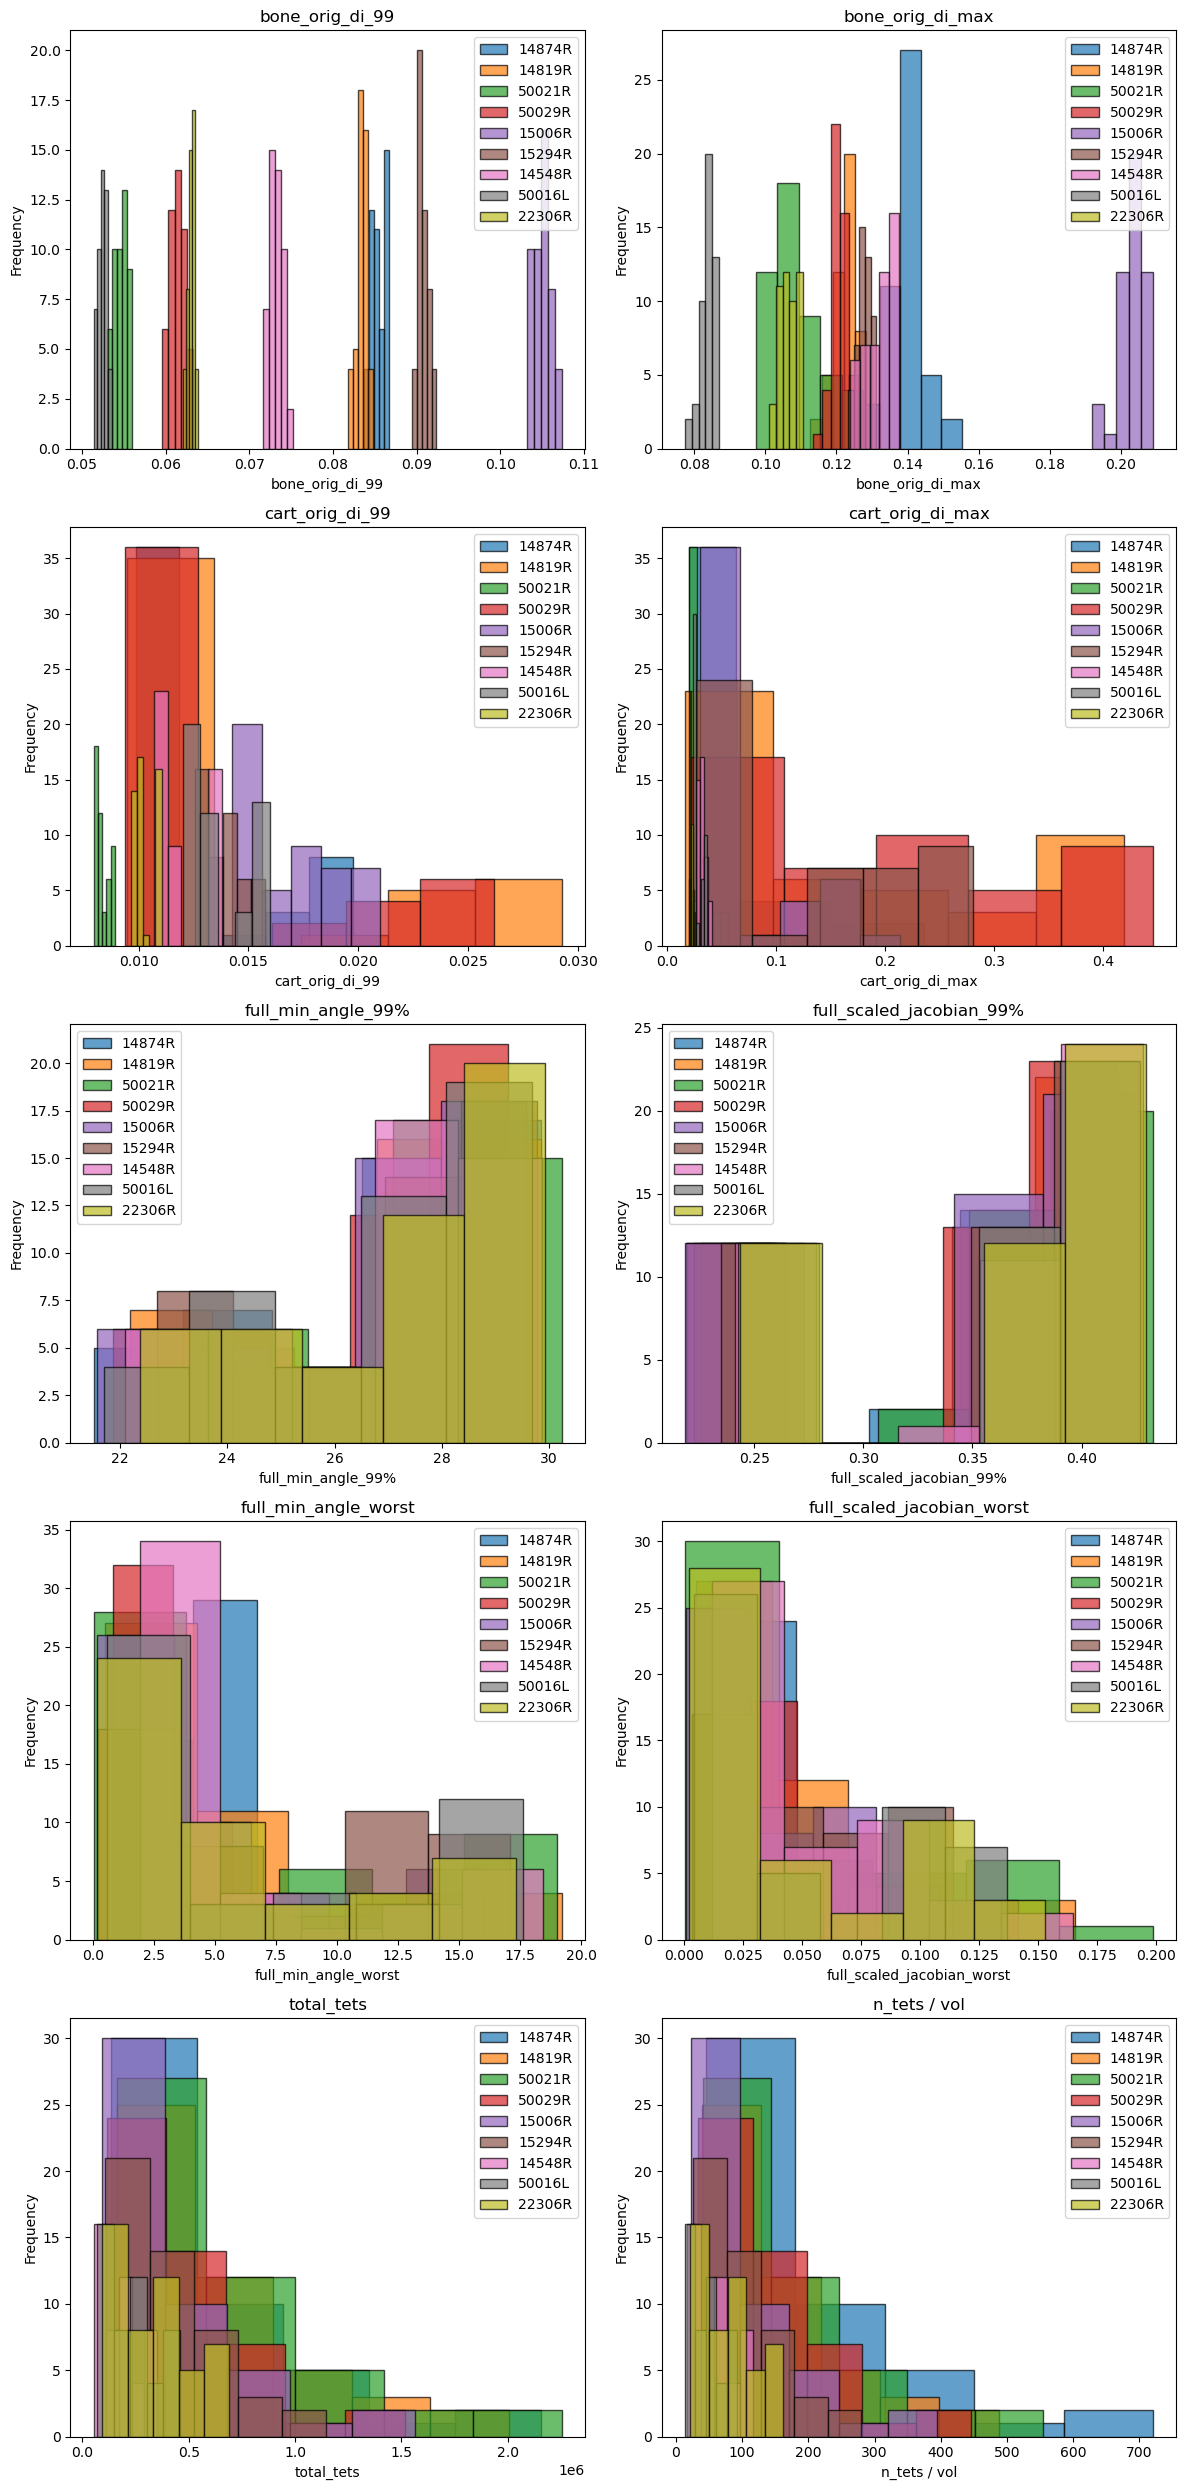

In [115]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()


for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    orig_vol = info[(info['subject']==int(subject)) & (info['side']==side)]['tpm_volume'].values
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    print(f"{sub} - Average edge length: {L:.4f} mm")

    sub_df = df[df['sub']==sub]
    bins = round(len(sub_df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        ax[i].legend()

    #ax[-1].hist(100 * (sub_df['remesh3d_vol'].values - orig_vol) / orig_vol, bins=bins, edgecolor='black', alpha=0.7)
    ax[-1].hist(sub_df['tets_vol'], bins=bins, edgecolor='black', alpha=0.7, label=sub)
    ax[-1].set_title("n_tets / vol")
    ax[-1].set_xlabel("n_tets / vol")
    ax[-1].set_ylabel('Frequency')
    ax[-1].legend()

plt.tight_layout()
plt.show()

## Scores
 - bigger sizing field is better
 - Think n_tets = 3 ranks best because taper_region tet size was set to 0.2, which blends best with 3 tets
 - 15006 seemed to struggle with quality a lot, assuming because they have very high cartilage height std

In [116]:
#d_weight = 1
q_weight = 1 
t_weight = 2

chosen_metrics = {
    #'bone_orig_di_max': {
    #    'ideal': 0.15,
    #    'acceptable': 0.25,
    #    'weight': d_weight
    #},
    #'cart_orig_di_max': {
    #    'ideal': 0.025,
    #    'acceptable': 0.05,
    #    'weight': d_weight
    #},

    #f'{qual_part}_min_angle_99%': {
    #    'ideal': 30,
    #    'acceptable': 15,
    #    'weight': q_weight
    #},
    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },
    #f'{qual_part}_scaled_jacobian_99%': {
    #    'ideal': 0.4,
    #    'acceptable': 0.3,
    #    'weight': q_weight
    #},
    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    #f'{qual_part}_aspect_ratio_99%': {
    #    'ideal': 3,
    #    'acceptable': 4,
    #    'weight': q_weight
    #},
    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
    #f'{qual_part}_radius_ratio_99%': {
    #    'ideal': 3,
    #    'acceptable': 4,
    #    'weight': q_weight
    #},
    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

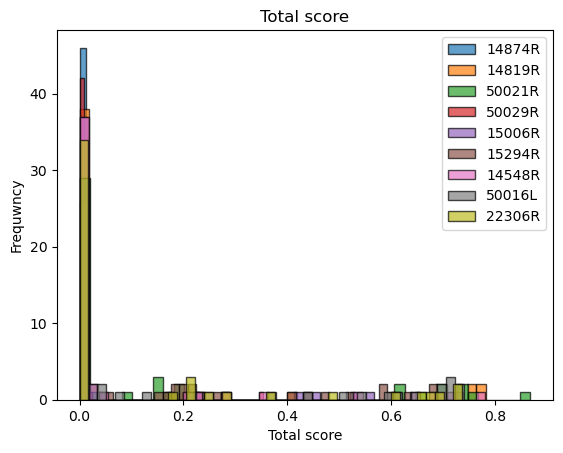

In [117]:
decay = 4
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)


fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [118]:
# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

In [119]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.sizing_field.n_tets,cgal_params.sizing_field.min_size,cgal_params.sizing_field.d0,mean_rank,median_rank,best_rank,n_runs
18,3,0.02,6,10.333333,6.0,2.0,9
23,3,0.04,8,15.555556,15.0,2.0,9
31,3,0.08,8,17.222222,13.0,1.0,9
22,3,0.04,6,17.444444,11.0,3.0,9
15,2,0.08,8,17.777778,12.0,1.0,9
3,2,0.02,8,18.000000,12.0,2.0,9
13,2,0.08,4,19.222222,21.0,6.0,9
42,4,0.06,6,19.333333,17.0,3.0,9
7,2,0.04,8,19.333333,18.0,1.0,9
21,3,0.04,4,20.222222,20.0,3.0,9


## Cell Counts: d0 / n_tets / min_size combos
---
 - For n_tets = 3 : 
    - Setting min_size = 0.06 has near zero effect on actual cartilage height for all but 7 subjects and max 2.5% of the area is affected
    - Setting min_size = 0.06 causes most to have some area of cartilage with < 3 tets, but affects < 5% of the area of all but 6
        - looked at < n_tets - 0.5 cos it will still be able fit 3 non perfect tets in the space between min_size*(n_test-0.5 -> n_tets)
---
- If min_size is limited to 0.06 and cell count is limited to ~500,000, then that gives us d0 ≤ 6mm
    - WHAT IS ACTUAL REASONABLE MAXIMUM AMOUNT OF CELLS ?

In [60]:
df_cells = pd.merge(df_qual[['sub', 'bone', 'run_id', 'total_tets']], df_param)


df_cells3 = df_cells[df_cells['cgal_params.sizing_field.n_tets'] == 3]
df_cells3

,sub,bone,run_id,total_tets,cgal_params.sizing_field.n_tets,cgal_params.sizing_field.min_size,cgal_params.sizing_field.d0
16,14874R,tpm,16-1b,722032,3,0.02,2
17,14874R,tpm,17-1b,901259,3,0.02,4
18,14874R,tpm,18-1b,1074028,3,0.02,6
19,14874R,tpm,19-1b,1242479,3,0.02,8
20,14874R,tpm,20-1b,480243,3,0.04,2
...,...,...,...,...,...,...,...
410,22306R,tpm,27-0d,390489,3,0.06,8
411,22306R,tpm,28-0d,224131,3,0.08,2
412,22306R,tpm,29-0d,279608,3,0.08,4
413,22306R,tpm,30-0d,335020,3,0.08,6


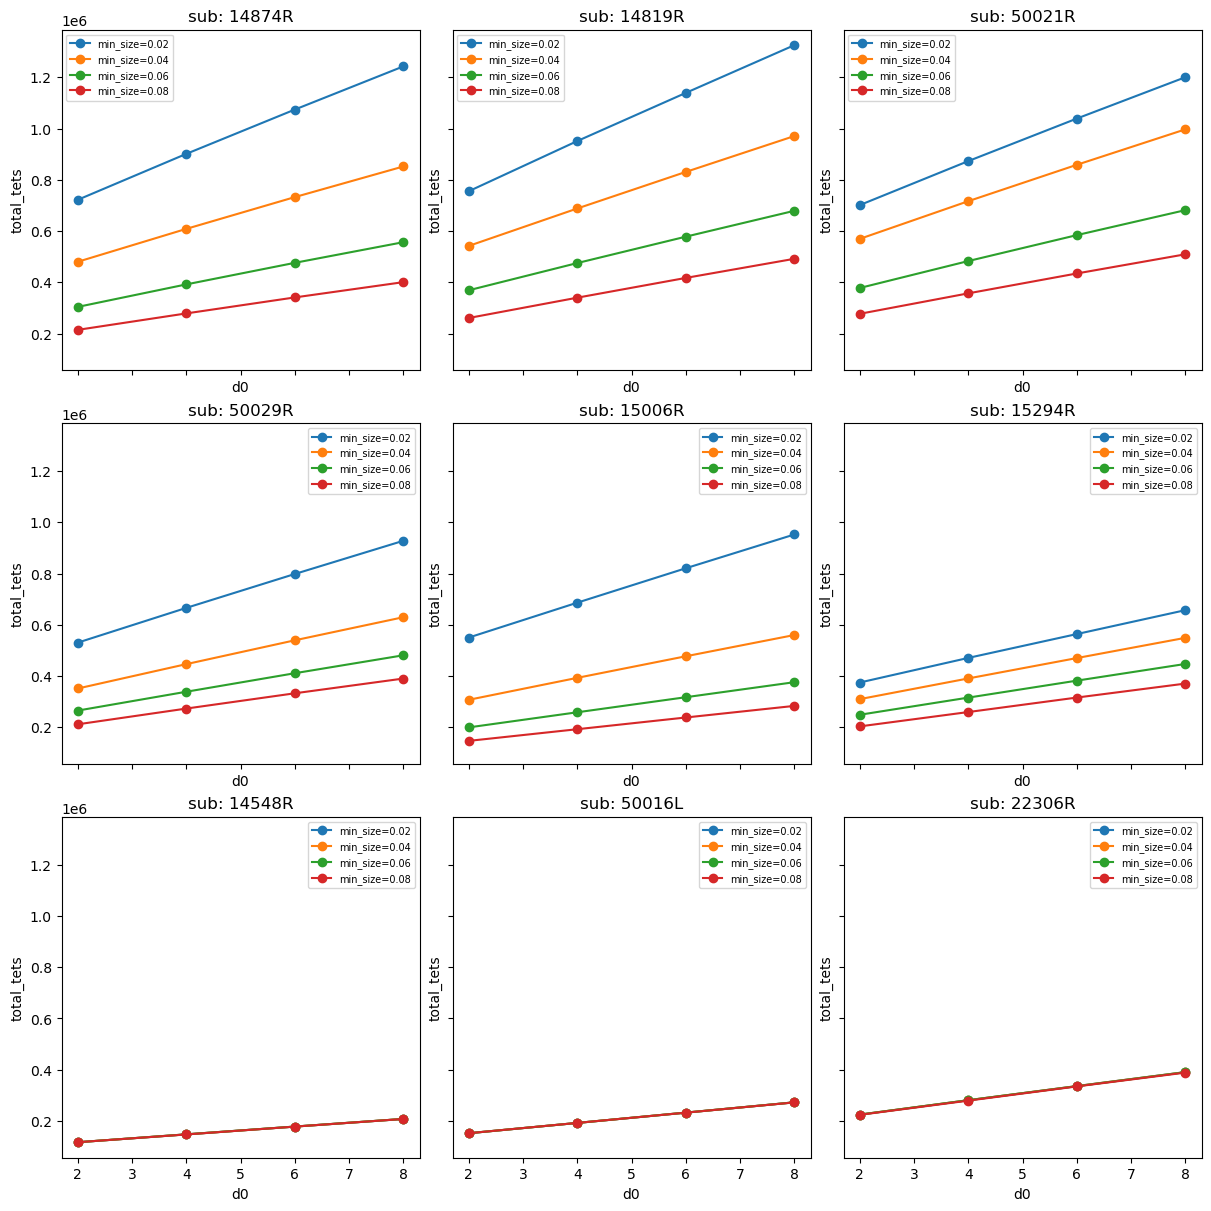

In [70]:
min_size_col = "cgal_params.sizing_field.min_size"
d0_col = "cgal_params.sizing_field.d0"

subjects = df["sub"].unique()

ncols = 3
nrows = np.ceil(len(subjects) / ncols).astype(int)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True, constrained_layout=True)
axes = axes.flatten()

for ax, sub in zip(axes, subjects):
    dsub = df[df["sub"] == sub].sort_values([min_size_col, d0_col])

    for min_size, g in dsub.groupby(min_size_col):
        ax.plot(g[d0_col], g["total_tets"], marker="o", label=f"min_size={min_size}")

    ax.set_title(f"sub: {sub}")
    ax.set_xlabel("d0")
    ax.set_ylabel("total_tets")
    ax.legend(fontsize=7)

for ax in axes[len(subjects):]:
    ax.axis("off")

plt.show()

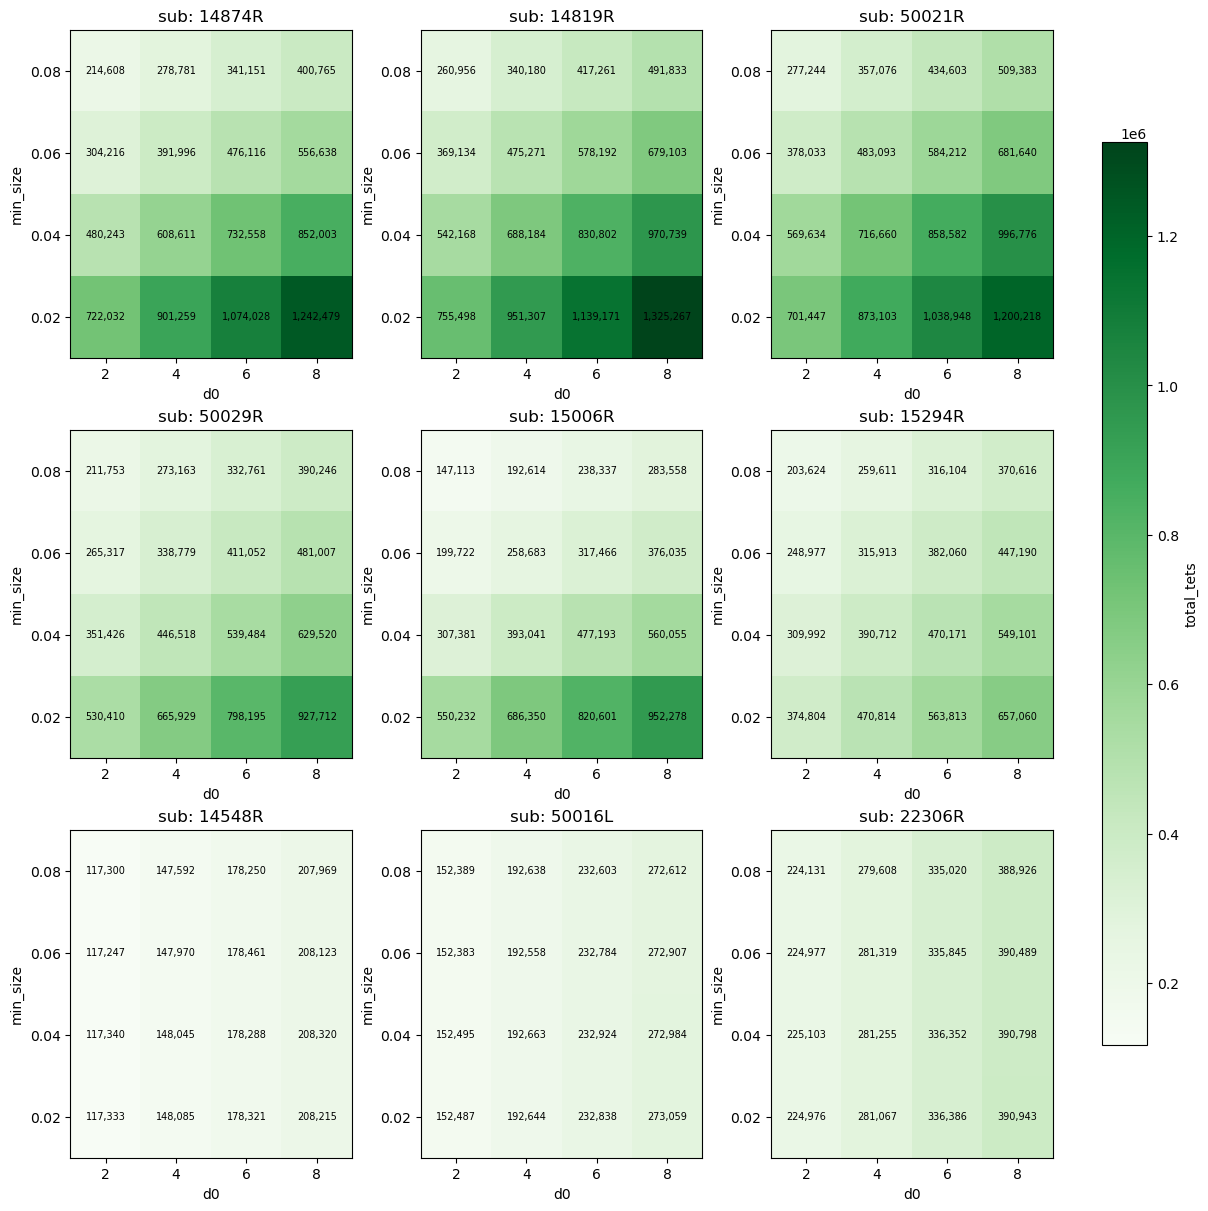

In [62]:
df = df_cells3

min_size_col = "cgal_params.sizing_field.min_size"
d0_col = "cgal_params.sizing_field.d0"

subjects = df["sub"].unique()

# layout
ncols = 3
nrows = np.ceil(len(subjects) / ncols).astype(int)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), constrained_layout=True)
axes = axes.flatten()

vmin = df["total_tets"].min()
vmax = df["total_tets"].max()

for ax, sub in zip(axes, subjects):
    dsub = df[df["sub"] == sub]

    # rows=min_size, cols=d0, values=total_tets
    pivot = dsub.pivot_table(
        index=min_size_col,
        columns=d0_col,
        values="total_tets",
        aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap='Greens'
    )

    ax.set_title(f"sub: {sub}")
    ax.set_xlabel("d0")
    ax.set_ylabel("min_size")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])

    # optional: write values in cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{int(val):,}", ha="center", va="center", fontsize=7)

# hide unused axes
for ax in axes[len(subjects):]:
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes[:len(subjects)], shrink=0.8)
cbar.set_label("total_tets")

plt.show()

### Area below min_size and below min_size * n_tets

In [109]:
# brought this in from cartilageHeight-box.ipynb

def cartilage_h_A(mesh2d, n_tets, min_sizes):
    """"return cartilage inner region height and proportion of inner area below min height"""

    bone_shell = mesh2d.extract_cells(mesh2d['region_id']==2, invert=True).extract_surface(algorithm=None)
    inner_cart = mesh2d.extract_cells(mesh2d['inner_cells']==1).extract_surface(algorithm=None)
    cart_height = inner_cart.cell_centers().compute_implicit_distance(bone_shell)['implicit_distance']

    As = inner_cart.compute_cell_sizes()['Area']
    A_inner = np.sum(As)

    A_data = {
        'A_below_h': [],
        'A_below_min': []
    }
    for min_size in min_sizes:
        min_h = (n_tets-0.5) * min_size 
        below_h_mask = cart_height < min_h # cell centers below min height
        below_min_mask = cart_height < min_size

        A_data['A_below_h'].append(np.sum(As[below_h_mask]) / A_inner) # proportion of area below n_tets
        A_data['A_below_min'].append(np.sum(As[below_min_mask]) / A_inner) # proportion of area below min height

    return cart_height, A_data 






n_tets = 3 
min_sizes = np.linspace(0.01, 0.10, 100)
bone_pair = 'tpm-mc1'

root_dir = Path('../cartilageHeightMetrics/outputs/subs_okJustified')
mesh2d_paths = list(root_dir.glob(f'**/{bone_pair}/**/bone_cartilage_mesh*.vtp'))

data = []
A_datas = {}
for mesh2d_path in tqdm(mesh2d_paths):

    bone, _ = mesh2d_path.parent.parent.name.split('-')
    sub = mesh2d_path.parents[2].name
    subject, side = sub[:-1], sub[-1]
    L = avg_edge_length(get_mesh(get_subject_stl_path(subject, side), 'tpm'))

    mesh2d = pv.read(mesh2d_path)
    cart_height, A_data  = cartilage_h_A(mesh2d, n_tets, min_sizes)
    A_datas[sub] = A_data

    data.append({
        'subject': sub,
        'bone': bone,
        'h_mean': cart_height.mean(),
        'h_min': cart_height.min(),
        'h_max': cart_height.max(),
        'h_std': np.std(cart_height),
        'L_orig': L
    })

100%|██████████| 36/36 [00:04<00:00,  7.86it/s]


In [110]:
df_height = pd.DataFrame(data).sort_values(['h_mean']).reset_index(drop=True)
df_height

,subject,bone,h_mean,h_min,h_max,h_std,L_orig
0,50021R,tpm,0.264730,0.065893,0.587196,0.120868,0.369239
1,14819R,tpm,0.266091,0.024729,0.651162,0.137645,0.440327
2,14874R,tpm,0.273480,0.039107,0.629595,0.142659,0.441794
3,50029R,tpm,0.299387,0.015210,0.609025,0.125528,0.368228
4,15283R,tpm,0.329545,0.093736,0.606070,0.101766,0.513917
5,50045R,tpm,0.340526,0.154803,0.675983,0.118881,0.366641
6,15294R,tpm,0.345202,0.022595,0.672916,0.141316,0.444981
7,50014R,tpm,0.357814,0.168335,0.730456,0.122832,0.364354
8,14726R,tpm,0.358475,0.140836,0.777017,0.121613,0.442901
9,50000R,tpm,0.369456,0.175002,0.568304,0.077913,0.366141


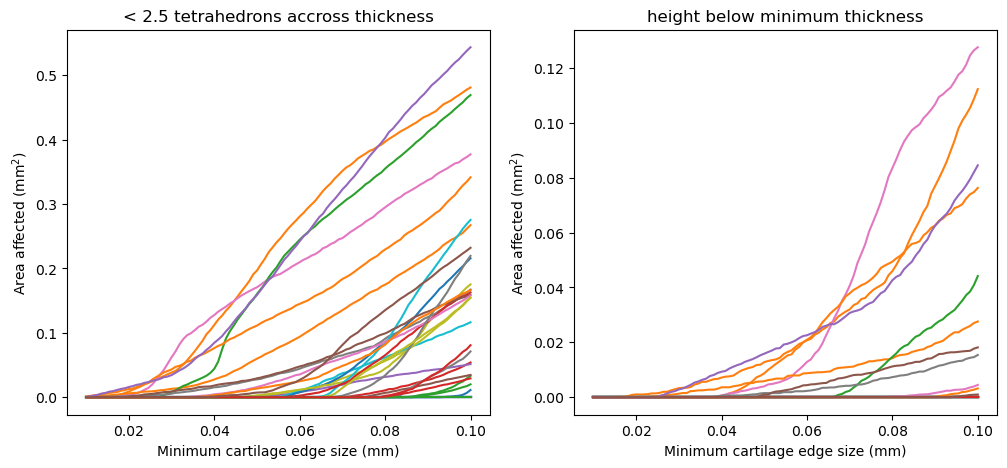

In [111]:
n_rows, n_cols = 1, 2
fig, ax = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
ax = ax.flatten()

subs = A_datas.keys()
for sub in subs:
    A_below_h = A_datas[sub]['A_below_h']
    A_below_min = A_datas[sub]['A_below_min']

    ax[0].plot(min_sizes, A_below_h)
    ax[0].set_title(f'< {n_tets-0.5} tetrahedrons accross thickness')
    ax[0].set_xlabel('Minimum cartilage edge size (mm)')
    ax[0].set_ylabel('Area affected (mm$^2$)')

    ax[1].plot(min_sizes, A_below_min)
    ax[1].set_title('height below minimum thickness')
    ax[1].set_xlabel('Minimum cartilage edge size (mm)')
    ax[1].set_ylabel('Area affected (mm$^2$)')


#### Thoughts
 - For n_tets = 3 : 
    - Setting min_size = 0.06 has near zero effect on actual cartilage height for all but 7 subjects and max 2.5% of the area is affected
    - Setting min_size = 0.06 causes most to have some area of cartilage with < 3 tets, but affects < 5% of the area of all but 6
        - looked at < n_tets - 0.5 cos it will still be able fit 3 non perfect tets in the space between min_size*(n_test-0.5 -> n_tets)
---
- If min_size is limited to 0.06 and cell count is limited to ~500,000, then that gives us d0 ≤ 6mm
    - WHAT IS A REASONABLE MAXIMUM AMOUNT OF CELLS ?